<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\SharonLab\AppData\Local\Temp\ipykernel_24180\2612775792.py:32: SyntaxWarning: invalid escape sequence '\D'
  axes[i].set_xlabel('Frequency Deviation ($\Delta \omega$)')
C:\Users\SharonLab\AppData\Local\Temp\ipykernel_24180\2612775792.py:34: SyntaxWarning: invalid escape sequence '\D'
  axes[i].set_ylabel('Angular Deviation ($\Delta \theta$)')
C:\Users\SharonLab\AppData\Local\Temp\ipykernel_24180\2612775792.py:35: SyntaxWarning: invalid escape sequence '\o'
  fig.colorbar(im, ax=axes[i], label='Intensity $I_{2\omega}$')


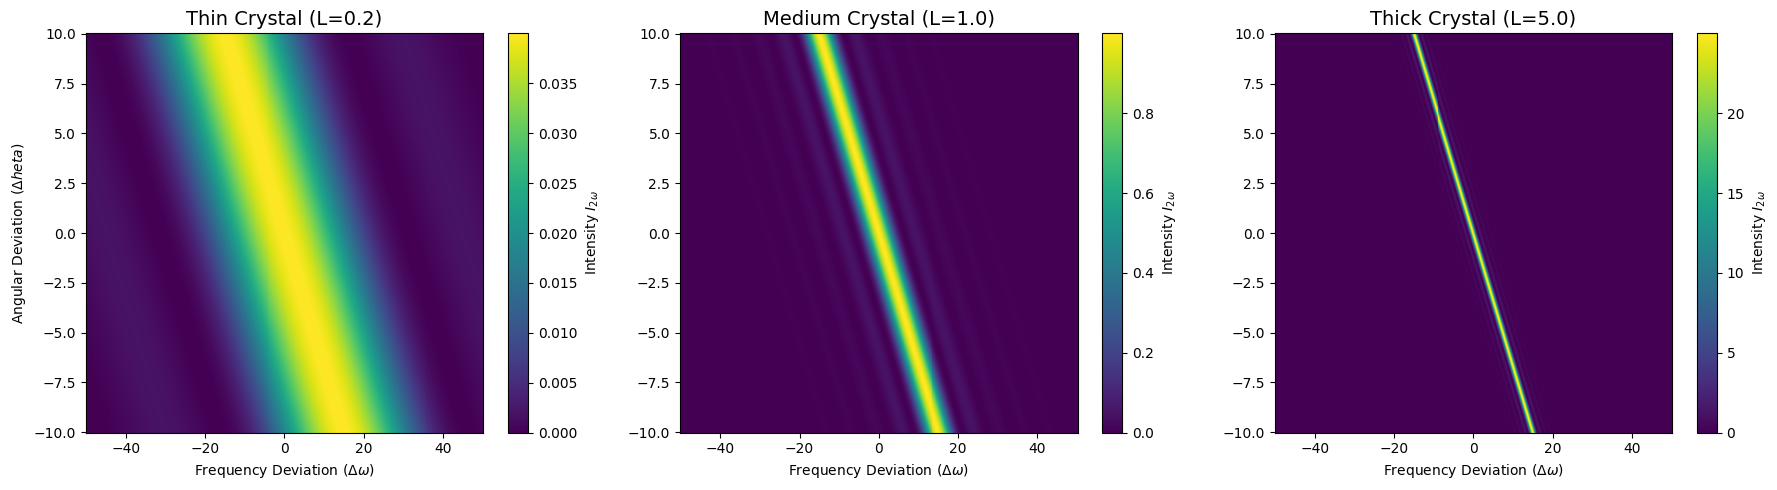

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_shg_intensity():
    # הגדרת טווחים עבור סטיית תדר (dw) וסטיית זווית (dtheta)
    dw = np.linspace(-50, 50, 400)
    dtheta = np.linspace(-10, 10, 400)
    DW, DTHETA = np.meshgrid(dw, dtheta)

    # מקדמי רגישות (ערכים טיפוסיים להמחשה)
    beta_w = 1.0  # רגישות לתדר
    beta_t = 1.5  # רגישות לזווית

    # עוביי גביש שונים (יחידות שרירותיות)
    L_values = [0.2, 1.0, 5.0]
    titles = ['Thin Crystal (L=0.2)', 'Medium Crystal (L=1.0)', 'Thick Crystal (L=5.0)']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, L in enumerate(L_values):
        # חישוב דלתא k
        dk = beta_w * DW + beta_t * DTHETA

        # חישוב עוצמת SHG לפי פונקציית sinc^2
        phase_arg = (dk * L) / 2
        # שימוש ב-np.sinc ב-numpy הוא sin(pi*x)/(pi*x), לכן נתאים את הארגומנט
        intensity = (L**2) * (np.sinc(phase_arg / np.pi)**2)

        # ציור מפת העוצמה
        im = axes[i].pcolormesh(DW, DTHETA, intensity, cmap='viridis', shading='auto')
        axes[i].set_title(titles[i], fontsize=14)
        axes[i].set_xlabel('Frequency Deviation ($\Delta \omega$)')
        if i == 0:
            axes[i].set_ylabel('Angular Deviation ($\Delta \theta$)')
        fig.colorbar(im, ax=axes[i], label='Intensity $I_{2\omega}$')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_shg_intensity()